# Introduction to TummyTribe Project
In this project, we dive into an infant gut microbiome cohort, using QIIME2 to transform diaper-derived sequences into scientific insight. By integrating fecal microbiome data with detailed sample metadata, we aim to find microbial signatures shaping early-life gut health, helping the TummyTribe mission turn tiny diapers into big discoveries.

<span style="font-size:8px">Disclaimer: We put in a lot of coffee breaks for code that takes a long time to run. We are not responsible for any caffeine addiction.</span>

# 1. Data Import and Overview
In this notebook, we download the raw data and perform an initial data exploration.
### Notebook Structure
**1.** Setup  
&nbsp;&nbsp;&nbsp;&nbsp;**1.1** Environment   
&nbsp;&nbsp;&nbsp;&nbsp;**1.2** Import Packages  
&nbsp;&nbsp;&nbsp;&nbsp;**1.3** Set Working Directory  
&nbsp;&nbsp;&nbsp;&nbsp;**1.4** Download the Data  
&nbsp;&nbsp;&nbsp;&nbsp;**1.5** Merge Metadata  
  
**2.** Exploratory Data Analysis  
&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Metadata  
&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Sequence data 

## 1. Setup
### 1.1 Environment
All notebooks run entirely on JupyterHub. When additional packages are needed, they are installed directly within the corresponding notebooks. Some steps exceed the available JupyterHub RAM (8 GB), so they are executed as bash scripts on Euler. Each of these notebooks specifies where to find the related script and its environment configuration file. The resulting files from Euler are transferred back into the JupyterHub notebooks via wget using Polybox links.

In [1]:
# Check the current JupyterHub QIIME2 versions
!qiime info

System versions
Python version: 3.10.14
QIIME 2 release: 2025.7
QIIME 2 version: 2025.7.0
q2cli version: 2025.7.0

Installed plugins
alignment: 2025.7.0
annotate: 2025.7.0
assembly: 2025.7.0
boots: 0.0.1+162.g946b12e
composition: 2025.7.0
cutadapt: 2025.7.0
dada2: 2025.7.0
deblur: 2025.7.0
demux: 2025.7.0
diversity: 2025.7.0
diversity-lib: 2025.7.0
emperor: 2025.7.0
feature-classifier: 2025.7.0
feature-table: 2025.7.0
fondue: 2025.7.0
fragment-insertion: 2025.7.0
kmerizer: 0.0.1+37.gfd404f7
longitudinal: 2025.7.0
metadata: 2025.7.0
phylogeny: 2025.7.0
quality-control: 2025.7.0
quality-filter: 2025.7.0
rescript: 2025.7.0
sample-classifier: 2025.7.0
sourmash: 0.0.0
stats: 2025.10.0.dev0+3.g0e345b9
taxa: 2025.7.0
types: 2025.7.0
vizard: 2025.10.0.dev0+13.g6acebbb
vsearch: 2025.7.0

Application config directory
/opt/conda/envs/checkm/var/q2cli

Config
Config Source: /opt/conda/envs/checkm/etc/qiime2_config.toml

Getting help
To find help and learning resources, visit https://qiime2.org.
To

### 1.2 Import Packages

In [2]:
# Import all necessary packages
import IPython
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from qiime2 import Visualization
import pandas as pd
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1.3 Set Working Directory
Ensure that the working directory is correctly set to the 'scripts' folder within the main project directory. 
Otherwise, the file paths used in this notebook may not work properly.

In [3]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [4]:
# Data directory for the raw and processed data
data_dir = "../data/raw"
meta_data_dir = "../data/processed/metadata"
# Create the metadata folder

In [5]:
%%bash -s "$meta_data_dir"
mkdir -p "$1"

### 1.4 Download the Data

First, we download the raw data and additional metadata information.

In [6]:
%%bash -s "$data_dir"

# $1 = data_dir

mkdir -p "$1"      # ensure raw directory exists
cd "$1"            # move into raw directory

# Download files directly into raw folder
wget -O metadata.tsv "https://polybox.ethz.ch/index.php/s/aNpBCyFwxfSfEFq/download"
wget --progress=bar:force:noscroll -O sequences-demux-paired.qza \
    "https://polybox.ethz.ch/index.php/s/f4XQxriGrKqBcsm/download"

# Download the supplementary metadata
wget --content-disposition -O metadata_suppl.tsv "https://polybox.ethz.ch/index.php/s/XBFRHYnSswXpcE6/download"

echo "Downloaded into:"
pwd
ls -lh

--2025-12-18 14:33:13--  https://polybox.ethz.ch/index.php/s/aNpBCyFwxfSfEFq/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20838 (20K) [application/octet-stream]
Saving to: ‘metadata.tsv’

     0K .......... ..........                                 100% 2.42M=0.008s

2025-12-18 14:33:13 (2.42 MB/s) - ‘metadata.tsv’ saved [20838/20838]

--2025-12-18 14:33:13--  https://polybox.ethz.ch/index.php/s/f4XQxriGrKqBcsm/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4036859939 (3.8G) [application/octet-stream]
Saving to: ‘sequences-demux-paired.qza’

sequences-demux-pai 100%[===================>]   3.76G   150MB/s    in 26s     

2025-12-18 14:33:40 (146 MB/s) - ‘sequences-de

Downloaded into:
/home/jovyan/MicrobiomeAnalysis_TummyTribe/data/raw
total 4.2G
-rw-r--r-- 1 jovyan jovyan  21K Dec 18 14:33 metadata.tsv
-rw-r--r-- 1 jovyan jovyan 8.1K Dec 18 14:33 metadata_suppl.tsv
-rw-r--r-- 1 jovyan jovyan 3.8G Dec 18 14:33 sequences-demux-paired.qza
-rw-r--r-- 1 jovyan jovyan 335K Nov 13 10:19 sequences-demux-paired.qzv
-rw-r--r-- 1 jovyan jovyan 209M Oct 20 09:21 silva-138-99-nb-human-stool-weighted-classifier.qza
-rw-r--r-- 1 jovyan jovyan 212M Oct 21 11:27 silva-138.2-ssu-nr99-classifier.qza


### 1.5 Merge Metadata
To complete the metadata, we merge the primary metadata table with the supplemental metadata containing age-in-days information for each child. We got this additional metadata later during the project, which is why the information is not in the first metadata.

In [7]:
# Load files
meta = pd.read_csv(f"{data_dir}/metadata.tsv", sep="\t")
meta_suppl = pd.read_csv(f"{data_dir}/metadata_suppl.tsv", sep="\t")

# Use first column of metadata_suppl as merge key
first_col = meta_suppl.columns[0]

# Merge
meta_merged = meta.merge(
    meta_suppl,
    left_on=["id", "host_id"],
    right_on=[meta_suppl.columns[0], "host_id"],
    how="left"
)

# Drop duplicate SRR column
meta_merged = meta_merged.drop(columns=[first_col])

# Ensure processed folder exists
os.makedirs(f"{meta_data_dir}", exist_ok=True)

# Save merged metadata
out_path = f"{meta_data_dir}/metadata_merged.tsv"
meta_merged.to_csv(out_path, sep="\t", index=False)

## 2. Exploratory Data Analysis
### 2.1 Metadata
Now, we will have a look at our merged metadata.

In [8]:
# Load the metadata as a pandas data frame & have a look at it
print("First few rows of the metadata: \n", meta_merged.head(), "\n")
print(f"Metadata has {meta_merged.shape[0]} rows and {meta_merged.shape[1]} columns.")

First few rows of the metadata: 
            id  host_id  age_months geo_location_name delivery_mode     sex  \
0  SRR8118533  E000823         4.0           Finland       vaginal    male   
1  SRR8118537  E000823         7.0           Finland       vaginal    male   
2  SRR8118564  E001958         4.0           Finland       vaginal  female   
3  SRR8118650  E001958         7.0           Finland       vaginal  female   
4  SRR8118652  E001958        10.0           Finland       vaginal  female   

  diet_weaning diet_milk  treatment_exposure  age_days  
0           no        bd               False       121  
1          yes     mixed               False       205  
2          yes        bd               False       129  
3          yes     mixed               False       223  
4          yes     mixed               False       319   

Metadata has 357 rows and 10 columns.


The metadata contains extra information about the 357 samples. Each sample has its own identifier (id) and an id showing which child it comes from (host_id). The child’s age at the time of sampling is recorded in both months (age_months) and days (age_days). Other information includes the child’s country (geo_location_name), birth delivery type (delivery_mode), and sex. The metadata also provides insight into the children’s diet. Diet_weaning shows whether the child had started eating solid foods and diet_milk describes the main type of milk or feeding pattern. Finally, treatment_exposure indicates whether the child had received any treatment before the sample was taken.
#### Missing data
We compute the number of missing values in each column, both as counts and as percentages.

In [9]:
# Compute the number of missing values for each column as counts and as percentage
missing_df = pd.DataFrame({
    'count': meta_merged.isna().sum(),
    'percentage': round((meta_merged.isna().sum() / len(meta_merged)) * 100,1)})
print("Number of missing values for each column:")  
print(missing_df)

Number of missing values for each column:
                    count  percentage
id                      0         0.0
host_id                 0         0.0
age_months              0         0.0
geo_location_name       0         0.0
delivery_mode           0         0.0
sex                     0         0.0
diet_weaning           23         6.4
diet_milk              87        24.4
treatment_exposure      0         0.0
age_days                0         0.0


Except for the diet-related columns, there are no missing values in the metadata.
#### Overview of samples per child
Next, we count the total number of children in our dataset and then group the data by child (host_id) to examine the number of samples per child and the number of unique sampling ages (in months).

In [10]:
# Number of children
n_children = len(pd.unique(meta_merged["host_id"]))
print(f"There are {n_children} children in the dataset.")

There are 190 children in the dataset.


Number of samples per child: 
number_samples
1    72
2    72
3    43
4     3
Name: count, dtype: int64

Children with 4 samples: 
     host_id            sample_ages  number_samples  number_unique_ages
30  E011878  [4.0, 4.0, 7.0, 10.0]               4                   3
49  E017497  [4.0, 4.0, 7.0, 10.0]               4                   3
56  E019763  [4.0, 4.0, 7.0, 10.0]               4                   3

Look at child with host_id = 'E017497' in more detail: 
              id  host_id  age_months geo_location_name delivery_mode   sex  \
108  SRR8119075  E017497         4.0           Finland       vaginal  male   
109  SRR8119597  E017497         4.0           Finland       vaginal  male   
110  SRR8119321  E017497         7.0           Finland       vaginal  male   
111  SRR8119589  E017497        10.0           Finland       vaginal  male   

    diet_weaning diet_milk  treatment_exposure  age_days  
108          yes        bd               False       109  
109          yes  

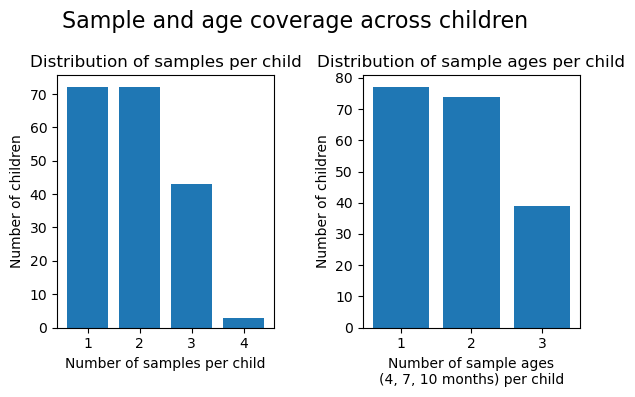

In [11]:
# Group per child
host_ids = meta_merged["host_id"].unique()
samples_per_child = []

for child in host_ids:
    child_data = meta_merged[meta_merged["host_id"] == child]
    
    # Create a list with all sample ages per child
    sample_ages = child_data["age_months"].to_list() 
    
    # Count total number of samples per child
    number_samples = len(sample_ages) 
    
    # Count unique ages per child
    number_unique_ages = len(set(sample_ages))  
    samples_per_child.append({"host_id": child, "sample_ages": sample_ages, "number_samples": number_samples, "number_unique_ages": number_unique_ages})
    
samples_per_child = pd.DataFrame(samples_per_child)
# print(samples_per_child)

# Create counts for the number of samples per child
counts = samples_per_child["number_samples"].value_counts().sort_index()
print(f"Number of samples per child: \n{counts}\n")

print("Children with 4 samples: \n", samples_per_child[samples_per_child["number_samples"] == 4])
print("\nLook at child with host_id = 'E017497' in more detail: \n", meta_merged[meta_merged["host_id"] == "E017497"])

# Create counts for the number of uniaue sample ages per child
unique_age_counts = samples_per_child["number_unique_ages"].value_counts().sort_index()
print(f"\nNumber of samples with unique ages (in months): \n{unique_age_counts}")

# Create barplots for the counts (for the presentation & report)
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_xlabel("Number of samples per child")
axes[0].set_ylabel("Number of children")
axes[0].set_title("Distribution of samples per child")
axes[1].bar(unique_age_counts.index.astype(str), unique_age_counts.values)
axes[1].set_xlabel("Number of sample ages\n(4, 7, 10 months) per child")
axes[1].set_ylabel("Number of children")
axes[1].set_title("Distribution of sample ages per child")

plt.suptitle("Sample and age coverage across children", fontsize=16)
plt.tight_layout(w_pad=3)

The results show that most of the 190 children have only one or two samples. Only 39 children have data for all three target ages (4, 7, and 10 months) and several children have more than one sample recorded at the same age in months. For example, the child with host_id E017497 has two samples labeled as 4 months. One entry indicates predominant breastfeeding, while the other reports a mixed diet. Since a child cannot have two different feeding statuses at a single visit, we consulted our teaching assistant. She clarified that the age in months values had been averaged and these samples were actually collected at two separate visits a few days apart. This is evident when examining the age in days column, which we added later from the supplementary metadata.

#### Distribution in age
We generate a histogram showing the distribution of the additional variable age in days.

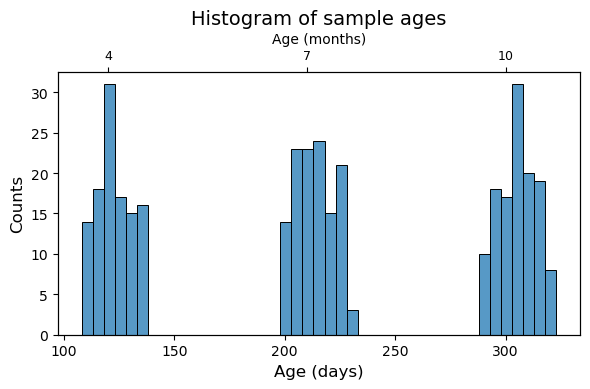

In [12]:
fig, ax = plt.subplots(figsize=(6,4))

# Plot histogram using days
sns.histplot(data=meta_merged, x='age_days', binwidth=5, ax=ax)

# Primary x-axis: days (bottom)
ax.set_xlabel("Age (days)", fontsize=12)
ax.set_ylabel("Counts", fontsize=12)
ax.set_title("Histogram of sample ages", fontsize=14)

# Secondary x-axis: months (top)
ax_top = ax.twiny()  # create a second axis on top 
ax_top.set_xlim(ax.get_xlim())  # match the same scale
ax_top.set_xticks([4*30, 7*30, 10*30])  # positions in days
ax_top.set_xticklabels([4, 7, 10], fontsize = 9)      # labels in months
ax_top.set_xlabel("Age (months)", fontsize=10)

plt.tight_layout()

Most children are quite close to the age categories (4, 7, and 10 months).
#### Consistency of metadata across sampling ages
To ensure the metadata is consistent, we check whether certain characteristics remain the same for each child over time. Specifically, we verify that the child’s country of origin, birth delivery mode, and sex remain constant, while diet and treatment exposure can vary over time.

In [13]:
cat_col = ['geo_location_name', 'delivery_mode', 'sex', 'diet_weaning', 'diet_milk', 'treatment_exposure']

print("Number of children with changes over time per column:")
for col in cat_col:
    # Count the number of children where the column changes over time
    n_changes = (meta_merged.groupby('host_id')[col].nunique() > 1).sum()
    print(f"{col}: {n_changes}")

Number of children with changes over time per column:
geo_location_name: 0
delivery_mode: 0
sex: 0
diet_weaning: 26
diet_milk: 26
treatment_exposure: 0


As expected, the country, delivery mode, and sex remain the same for each child across all samples. Diet-related variables change over time for some children, reflecting normal developmental progress. Interestingly, treatment exposure also stays constant, even though we might expect changes as children grow and occasionally require treatment. However, without additional details on the type or timing of treatments, it is difficult to draw any conclusions.

#### Overview of the distributions in the metadata
Here, we examine how the metadata variables are distributed across the samples.

In [14]:
def get_palette(col, categories):
    cmap = COLOR_MAPS.get(col, {})
    return {
        cat: cmap.get(cat, COLOR_MISSING)
        for cat in categories
    }


COLOR_MISSING = "crimson"

COLOR_MAPS = {
    # -----------------
    # Diet (milk)
    # -----------------
    "diet_milk": {
        "bd": "#2ca02c",        # green
        "fd": "#ff7f0e",        # orange
        "mixed": "#1f77b4",     # blue
        "Missing": COLOR_MISSING
    },

    # -----------------
    # Treatment exposure
    # -----------------
    "treatment_exposure": {
        True: "#ff7f0e",      
        False: "#1f77b4",  
        "Missing": COLOR_MISSING
    },

    # -----------------
    # Sex
    # -----------------
    "sex": {
        "male": "#1f77b4",
        "female": "#ff7f0e",
        "Missing": COLOR_MISSING
    },

    # -----------------
    # Delivery mode
    # -----------------
    "delivery_mode": {
        "vaginal": "#1f77b4",
        "cesarean": "#ff7f0e",  
        "Missing": COLOR_MISSING
    },

    # -----------------
    # Country
    # -----------------
    "geo_location_name": {
        "Finland": "#1f77b4",   
        "Estonia": "#2ca02c",    
        "Russia": "#ff7f0e",   
        "Missing": COLOR_MISSING
    },

    # -----------------
    # Weaning diet
    # -----------------
    "diet_weaning": {
        "yes": "#2ca02c",       
        "no": "#1f77b4",        
        "Missing": COLOR_MISSING
    }
}

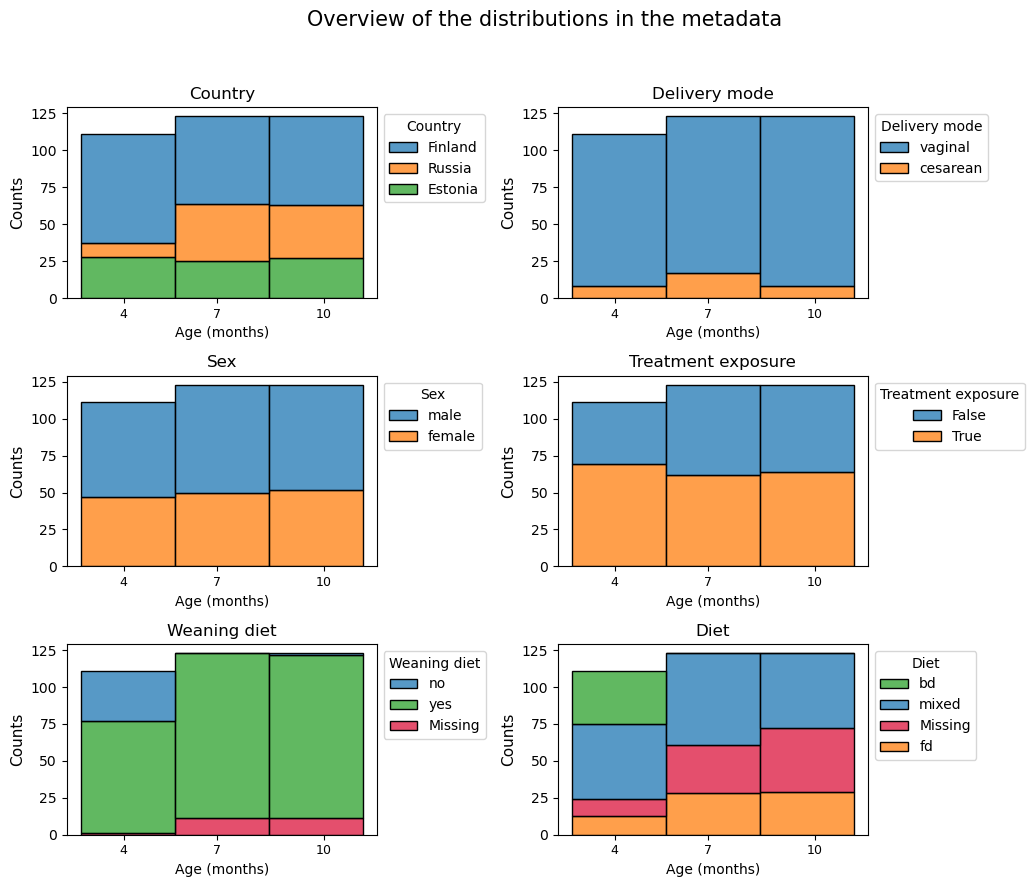

In [15]:
plot_data = meta_merged.copy()

cat_col = [
    "geo_location_name",
    "delivery_mode",
    "sex",
    "treatment_exposure",
    "diet_weaning",
    "diet_milk"
]

cat_names = [
    "Country",
    "Delivery mode",
    "Sex",
    "Treatment exposure",
    "Weaning diet",
    "Diet"
]

fig, axes = plt.subplots(3, 2, figsize=(11, 9))
axes = axes.flatten()
fig.suptitle("Overview of the distributions in the metadata", fontsize=15)

for i, col in enumerate(cat_col):
    ax = axes[i]

    plot_data[col] = plot_data[col].fillna("Missing")
    categories = plot_data[col].unique()
    palette = get_palette(col, categories)

    sns.histplot(
        data=plot_data,
        x="age_days",
        hue=col,
        multiple="stack",
        bins=3,
        ax=ax,
        palette=palette
    )

    ax.set_title(cat_names[i])
    ax.set_ylabel("Counts", fontsize=11)
    ax.set_xlabel("Age (months)", fontsize=10)
    ax.set_xticks([140, 210, 290])
    ax.set_xticklabels([4, 7, 10], fontsize=9)

    # Get the legend created by Seaborn and reposition it
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(cat_names[i])                    
        legend.set_bbox_to_anchor((1, 1)) 
        legend._loc = 2


#Hide unused axes
for j in range(len(cat_col), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.savefig("metadata_1.png", dpi=300, bbox_inches="tight")
plt.show()

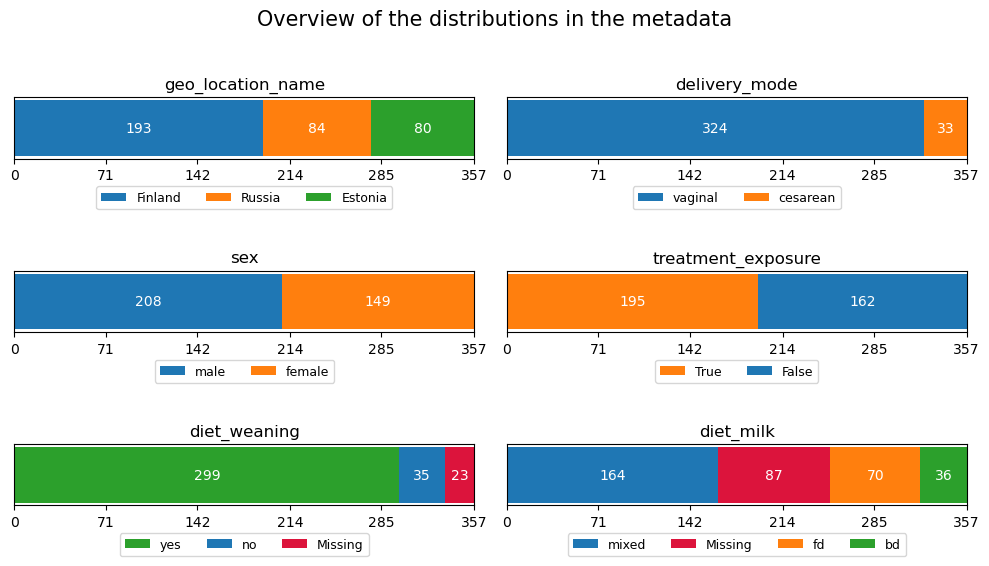

In [16]:
cat_col = [
    "geo_location_name",
    "delivery_mode",
    "sex",
    "treatment_exposure",
    "diet_weaning",
    "diet_milk"
]

max_count = meta_merged.shape[0]
n_rows = int(np.ceil(len(cat_col) / 2))

fig, axes = plt.subplots(n_rows, 2, figsize=(10, n_rows * 2))
axes = axes.flatten()
fig.suptitle("Overview of the distributions in the metadata", fontsize=15)

for i, col in enumerate(cat_col):
    ax = axes[i]

    counts = meta_merged[col].value_counts(dropna=False)
    counts.index = counts.index.fillna("Missing")

    left = 0

    for category, count in counts.items():
        color = COLOR_MAPS.get(col, {}).get(category, "#7f7f7f")

        ax.barh(
            y=0,
            width=count,
            left=left,
            height=0.5,
            color=color,
            label=str(category)
        )

        ax.text(
            left + count / 2,
            0,
            str(count),
            ha="center",
            va="center",
            fontsize=10,
            color="white"
        )

        left += count

    ax.set_title(col)
    ax.set_yticks([])
    ax.set_xlim(0, max_count)
    ax.set_xticks(np.linspace(0, max_count, 6).astype(int))

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=4,
        fontsize=9,
        frameon=True
    )

# Hide unused subplots
for j in range(len(cat_col), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("metadata_2.png", dpi=300, bbox_inches="tight")
plt.show()


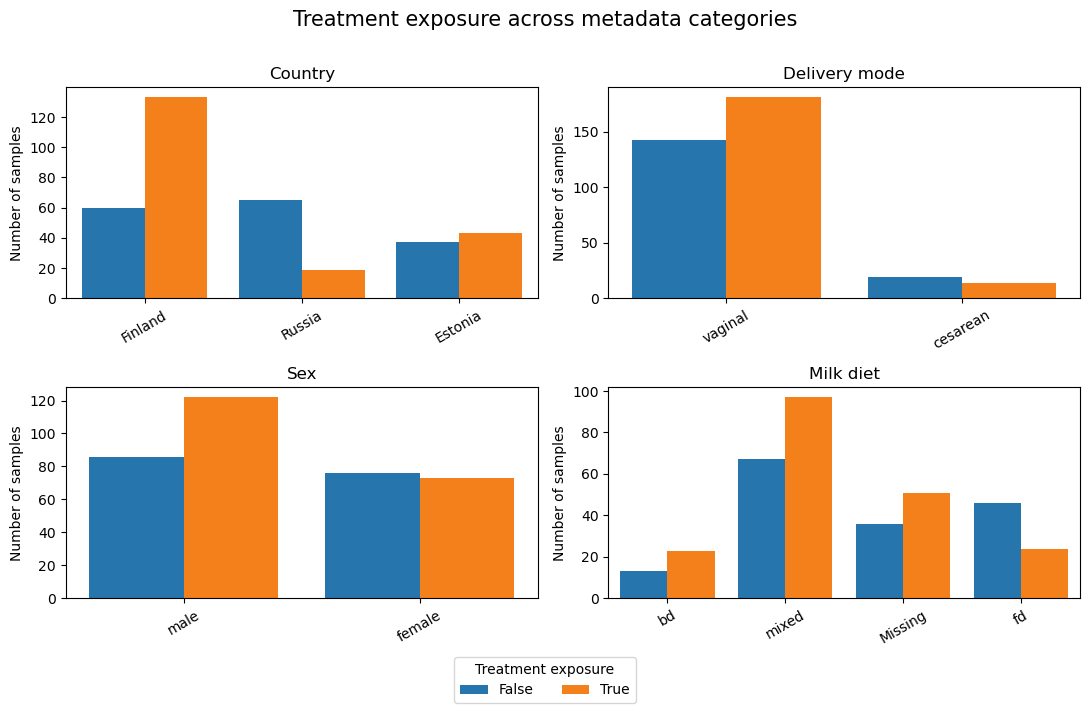

In [17]:
# Variables to check
cat_col = [
    "geo_location_name",
    "delivery_mode",
    "sex",
    "diet_milk"
]

cat_names = [
    "Country",
    "Delivery mode",
    "Sex",
    "Milk diet"
]

plot_data = meta_merged.copy()
plot_data["treatment_exposure"] = plot_data["treatment_exposure"].fillna("Missing")

# -----------------------
# Treatment colors
# -----------------------
TREATMENT_COLORS = {
    True: "#ff7f0e",     # blue
    False: "#1f77b4",   # orange
    "Missing": "crimson"
}

# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

fig.suptitle(
    "Treatment exposure across metadata categories",
    fontsize=15
)

legend_handles = None
legend_labels = None

for i, col in enumerate(cat_col):
    ax = axes[i]

    plot_data[col] = plot_data[col].fillna("Missing")

    sns.countplot(
        data=plot_data,
        x=col,
        hue="treatment_exposure",
        palette=TREATMENT_COLORS,
        ax=ax,
        saturation=0.90
    )

    ax.set_title(cat_names[i])
    ax.set_ylabel("Number of samples")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

    # Capture legend once
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.get_legend().remove()

# -----------------------
# Global legend BELOW plot
# -----------------------
fig.legend(
    legend_handles,
    legend_labels,
    title="Treatment exposure",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("treatment_metadata_overview_counts.png", dpi=300, bbox_inches="tight")
plt.show()


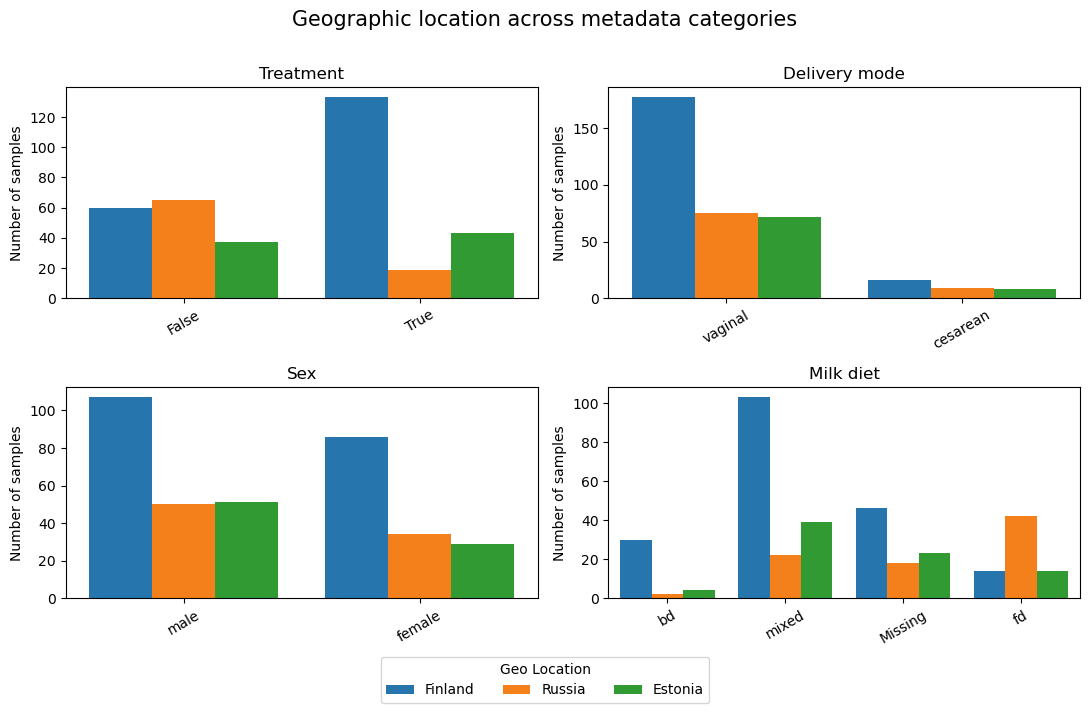

In [18]:
# Variables to check
cat_col = [
    "treatment_exposure",
    "delivery_mode",
    "sex",
    "diet_milk"
]

cat_names = [
    "Treatment",
    "Delivery mode",
    "Sex",
    "Milk diet"
]

plot_data = meta_merged.copy()
plot_data["geo_location_name"] = plot_data["geo_location_name"].fillna("Missing")

# -----------------------
# Treatment colors
# -----------------------
GEO_COLORS = {
        "Finland": "#1f77b4",   
        "Estonia": "#2ca02c",    
        "Russia": "#ff7f0e",   
        "Missing": COLOR_MISSING
    }

# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

fig.suptitle(
    "Geographic location across metadata categories",
    fontsize=15
)

legend_handles = None
legend_labels = None

for i, col in enumerate(cat_col):
    ax = axes[i]

    plot_data[col] = plot_data[col].fillna("Missing")

    sns.countplot(
        data=plot_data,
        x=col,
        hue="geo_location_name",
        palette=GEO_COLORS,
        ax=ax,
        saturation=0.90
    )

    ax.set_title(cat_names[i])
    ax.set_ylabel("Number of samples")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

    # Capture legend once
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.get_legend().remove()

# -----------------------
# Global legend BELOW plot
# -----------------------
fig.legend(
    legend_handles,
    legend_labels,
    title="Geo Location",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("geolocation_metadata_overview_counts.png", dpi=300, bbox_inches="tight")
plt.show()


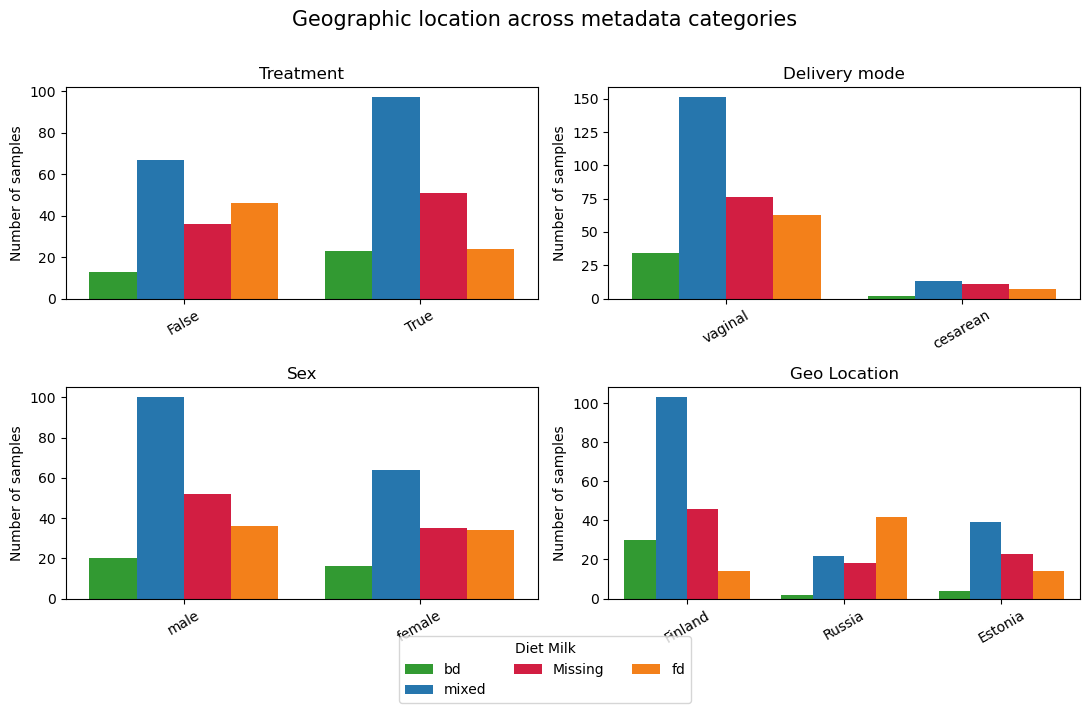

In [20]:
# Variables to check
cat_col = [
    "treatment_exposure",
    "delivery_mode",
    "sex",
    "geo_location_name"
]

cat_names = [
    "Treatment",
    "Delivery mode",
    "Sex",
    "Geo Location"
]

plot_data = meta_merged.copy()
plot_data["diet_milk"] = plot_data["diet_milk"].fillna("Missing")

# -----------------------
# Treatment colors
# -----------------------
DIET_MILK = {
    "bd": "#2ca02c",
    "fd": "#ff7f0e",
    "mixed": "#1f77b4",
    "Missing": COLOR_MISSING
}


# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

fig.suptitle(
    "Geographic location across metadata categories",
    fontsize=15
)

legend_handles = None
legend_labels = None

for i, col in enumerate(cat_col):
    ax = axes[i]

    plot_data[col] = plot_data[col].fillna("Missing")

    sns.countplot(
        data=plot_data,
        x=col,
        hue="diet_milk",
        palette=DIET_MILK,
        ax=ax,
        saturation=0.90
    )

    ax.set_title(cat_names[i])
    ax.set_ylabel("Number of samples")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

    # Capture legend once
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.get_legend().remove()

# -----------------------
# Global legend BELOW plot
# -----------------------
fig.legend(
    legend_handles,
    legend_labels,
    title="Diet Milk",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("diet_metadata_overview_counts.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from scipy.stats import chi2_contingency

vars_to_check = [
    "delivery_mode",
    "sex",
    "diet_milk",
    "diet_weaning",
    "geo_location_name",
    "treatment_exposure"
]

for var in vars_to_check:
    table = pd.crosstab(meta_merged[var], meta_merged["treatment_exposure"])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"treatment exposure; {var}: p = {p:.3e}")


for var in vars_to_check:
    table = pd.crosstab(meta_merged[var], meta_merged["geo_location_name"])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"geo location; {var}: p = {p:.3e}")

for var in vars_to_check:
    table = pd.crosstab(meta_merged[var], meta_merged["diet_milk"])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"diet_milk; {var}: p = {p:.3e}")    

In [ ]:
# cat_col = ['geo_location_name', 'delivery_mode', 'sex', 'treatment_exposure', 'diet_weaning', 'diet_milk']

# # Define the maximum number of samples
# max_count = meta_merged.shape[0]

# # Number of rows needed for 2 columns
# n_rows = round(len(cat_col) / 2)

# fig, axes = plt.subplots(n_rows, 2, figsize=(10, n_rows * 2))
# axes = axes.flatten()  # flatten for easy enumeration
# fig.suptitle('Overview of the distributions in the metadata', fontsize=15)

# for i, col in enumerate(cat_col):
#     ax = axes[i]
    
#     # Include missing values as a separate category
#     counts = meta_merged[col].value_counts(dropna=False)
#     counts.index = counts.index.fillna('Missing')
    
#     left = 0
#     bars = []
    
#     # Plot absolute counts as stacked horizontal bars
#     for category, count in counts.items():
#         color = 'crimson' if category == 'Missing' else None  # Missing values in red
#         bar = ax.barh(0, count, left=left, height=0.5, label=str(category), color=color)
#         # Add absolute number inside the bar
#         ax.text(left + count/2, 0, str(count), ha='center', va='center', fontsize=10, color='white')
#         left += count
#         bars.append(bar)
    
#     ax.set_title(col)
#     ax.set_yticks([])  # hide y-axis tick
#     ax.set_xlim(0, max_count)  # same x-axis for all bars
#     ax.set_xticks(np.arange(0, max_count + 1, step=max(1, max_count // 10)))
    
#     # Place the legend below the subplot
#     ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4, fontsize=10)

# # Hide any unused subplots
# for j in range(len(cat_col), len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# plt.savefig("meta_data_diet_1.png", dpi=300, bbox_inches="tight")

The bar plots show that the majority of samples come from Finland, with the remainder from Russia and Estonia. Most samples are from male children. The diet is predominantly breast fed (bd), predominantly formula fed (fd), or a mix of the two. Over 90% of the samples are from children born via vaginal delivery, 84% are from children whose parents had already started introducing solid foods, and around 55% of samples are from children who received treatment.

It is important to note that these distributions reflect the samples, not necessarily the number of children with each characteristic, since some children have up to four samples while others have only one.

Next, we explore how the distributions of these categorical variables vary across the different target ages.

In [ ]:
# # Plot the distribution of the metadata columns with age as additional information
# plot_data = meta_merged.copy()
# cat_col = ['geo_location_name', 'delivery_mode', 'sex', 'treatment_exposure', 'diet_weaning', 'diet_milk']
# cat_names = ['Country', 'Delivery mode', 'Sex', 'Treatment exposure', 'Weaning diet', 'Diet']

# fig, axes = plt.subplots(3, 2, figsize=(11, 9))
# axes = axes.flatten() # for axis enumeration
# fig.suptitle('Overview of the distributions in the metadata', fontsize=15)

# for i, col in enumerate(cat_col):
#     ax = axes[i]
    
#     # Fill missing values with 'Missing' for plotting
#     plot_data[col] = plot_data[col].fillna('Missing')
    
#     # Create a color palette with red for 'Missing' and default for others (because of the peer evaluation workshop feedback)
#     categories = plot_data[col].unique()
#     default_colors = sns.color_palette(n_colors=len(categories))
#     palette = {}
#     color_idx = 0
#     for cat in categories:
#         if cat == 'Missing':
#             palette[cat] = 'crimson'
#         else:
#             palette[cat] = default_colors[color_idx]
#             color_idx += 1
    
#     sns.histplot(data=plot_data, x='age_days', hue=col, multiple="stack", bins=3, ax=ax, palette=palette)
#     ax.set_title(cat_names[i])
#     ax.set_ylabel("Counts", fontsize=12)
#     ax.set_xticks([140, 210, 290])  # positions in days
#     ax.set_xticklabels([4, 7, 10], fontsize = 9) 
#     ax.set_xlabel("Age (months)", fontsize=10)
    
#     # Get the legend created by Seaborn and reposition it
#     legend = ax.get_legend()
#     if legend is not None:
#         legend.set_title(cat_names[i])                    
#         legend.set_bbox_to_anchor((1, 1)) 
#         legend._loc = 2

# plt.tight_layout()
# plt.savefig("meta_data_diet_2.png", dpi=300, bbox_inches="tight")

The number of samples from each country is fairly consistent across the three age groups, even though only a few samples from Russia are present at 4 months. The distributions of delivery mode, treatment exposure, and sex also remain relatively stable over time. Only one child had not yet begun weaning by 10 months and samples from predominantly breastfed children appear only at the 4-month time point.

Since some children contribute multiple samples while others have only one, these distributions reflect the samples rather than the number of children with each characteristic.

To better capture changes within individuals, we also generated the same plots using only the 39 children with one sample at each age. This approach allows us to observe how diet develops over time without the influence of differing sample counts across the age groups.

In [ ]:
# Identify children with all three ages
samples_per_child = meta_merged.groupby('host_id')['age_months'].nunique()
children_all_ages = samples_per_child[samples_per_child == 3].index

# Filter and take first sample per age per child
meta_one_per_age = meta_merged[meta_merged['host_id'].isin(children_all_ages)].groupby(['host_id', 'age_months'], as_index=False).first()
# print(meta_one_per_age.head(6))

# Plot the distribution of the metadata columns over time
plot_data = meta_one_per_age.copy()
cat_col = ['geo_location_name', 'delivery_mode', 'sex', 'treatment_exposure', 'diet_weaning', 'diet_milk']
cat_names = ['Country', 'Delivery mode', 'Sex', 'Treatment exposure', 'Weaning diet', 'Diet']

fig, axes = plt.subplots(3, 2, figsize=(11, 9))
axes = axes.flatten() # for axis enumeration
fig.suptitle('Overview of the distributions over time (only children with one sample for each age)', fontsize=15)

for i, col in enumerate(cat_col):
    ax = axes[i]
    
    # Fill missing values with 'Missing' for plotting
    plot_data[col] = plot_data[col].fillna('Missing')
    
    sns.histplot(data=plot_data, x='age_days', hue=col, multiple="stack", bins=3, ax=ax)
    ax.set_title(cat_names[i])
    ax.set_ylabel("Counts", fontsize=12)
    ax.set_xticks([140, 210, 290])  # positions in days
    ax.set_xticklabels([4, 7, 10], fontsize = 9) 
    ax.set_xlabel("Age (months)", fontsize=10)
    
    # Get the legend created by Seaborn and reposition it
    # Get the legend and reposition it
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(cat_names[i])                    
        legend.set_bbox_to_anchor((1, 1)) 
        legend._loc = 2

plt.tight_layout()

We can see that the distributions of country, delivery mode, sex and treatment exposure remain the same across all ages, since they come from the same children.

It is surprising that for these 39 children, 62% of the children had already started weaning at four months old. Most guidelines recommend beginning weaning no earlier than four months, with around six months being the ideal age, depending on the child’s development. However, as noted in several studies, many parents begin introducing solid foods earlier than recommended. A trend that is also reflected in our dataset. [[Sophie Nicklaus, 2011](https://doi.org/10.1016/j.appet.2011.05.321), [WHO, 2023](https://www.who.int/news-room/fact-sheets/detail/infant-and-young-child-feeding)]

By seven and ten months, it makes sense that all infants had already begun weaning. During the first four months of life, most infants were mainly breastfed, sometimes supplemented with formula. By seven to ten months, none were exclusively breastfed and most had a mixed diet. It is possible that the 'missing' values in the milk type data indicate that some infants were no longer receiving milk but were instead eating only solid foods. However, this is only a hypothesis, since we don't have access to the original data collection protocols.

### 2.2 Sequence data
Next, we take a look at the sequencing data.

In [ ]:
# Have a look at the QIIME 2 artifact of the sequencing data
! qiime tools peek $data_dir/sequences-demux-paired.qza

The sequencing data consists of paired-end, demultiplexed reads with Phred quality scores. According to the project description, the sequences are from the V4 region of the 16S rRNA gene and were generated using an Illumina MiSeq platform.

Further details on the sequencing data can be found in the next notebook (2. Quality Control and Denoising).

# References

Sophie Nicklaus, Children's acceptance of new foods at weaning. Role of practices of weaning and of food sensory properties, Appetite, Volume 57, Issue 3, 2011, Pages 812–815, ISSN 0195-6663. https://doi.org/10.1016/j.appet.2011.05.321

World Health Organization. (2023, December 20). Infant and young child feeding. https://www.who.int/news-room/fact-sheets/detail/infant-and-young-child-feeding